You can find the lecture [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/lectures/L03_probability.ipynb)
# Scope of the problem
Check that $$I\equiv\int_0^\infty x^3\ \exp\Big(-\frac{x^2}{2\sigma^2}\Big)\ dx=2\sigma^4$$
- Does the result converge with the number of samples? And how does the error go down?
- Do it many times. For a given $N$, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If $N$ is large enough you should get something that looks very accurate! And if $N$ is small?)
- How does the distribution change if $N$ increases?

In [18]:
import numpy as np
import pylab as plt

## Outline of the method
- Cast the integral in the following form:$$I=\int_a^b f(x)p(x)\ dx,$$where $p(x)$ is normalized to 1 over $[a,b]$. Put this way, $I$ may be thought of as $\langle f(x)\rangle$.
It is straightforward to identify $p(x)$ with the normal distribution over $[a,b]$,$$p(x)=\frac{1}{b-a},$$ and$$f(x)=x^3\ \exp\Big(-\frac{x^2}{2\sigma^2}\Big)$$Since we're dealing with an improper integral ($b=\infty$), we first sample $N$ points obeying the distribution $p(x)$ for finite $b$, then compute the integral as outlined above; at last, we'll take the limit of $I(b)$ as $b\to\infty$ by picking larger and larger values for $b$. We'll conclude that $I$ converges if $|I(b_i)-I(b_j)|\ll1$ for _any_ $b_i,b_j$ such that $|b_i-b_j|\ll1$ and $b_i>a\ \forall i$.
## Monte Carlo integration for variable $b$ and $N$

In [52]:
"""
We choose σ, set the minimum value for the upper extremum b, select 
the number of different b to be probed and, for fixed b, the number 
of different sample sizes. Overall, we work with a 1D-array n 
containing all the B x Σ_i^N 10^i random points
"""
#--------------------------------
sigma=1
b=100
B=10
N=8
n=np.repeat(10**np.arange(1,N),B)
#--------------------------------
xmax=b
xmin=0.
xi=np.random.uniform(xmin,xmax, n.sum())
def fun(x):
    return x**3*np.exp(-x**2/(2*sigma**2))
yi=fun(xi)
groups = np.repeat(np.arange(len(n)), n)
#--------------------------------
integral = (xmax-xmin) * np.bincount(groups, weights=yi) / n

## Plots

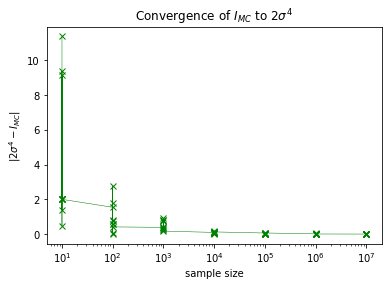

In [53]:
dist=np.abs(2*(sigma**4)*np.ones(B*(N-1),dtype=int)-integral)
plt.plot(n, dist, color='green', marker='x',linewidth=.5, markersize=6);
plt.xlabel('sample size')
plt.ylabel('|$2\sigma^4-I_{MC}$|')
plt.xscale('log')
plt.title('Convergence of $I_{MC}$ to $2\sigma^4$')
plt.show()